# 02 — VAE Applications

## 📚 Learning Objectives

By completing this notebook, you will:
- Know how VAEs power **face generation** and **style transfer** (concept walkthroughs — CelebA-scale training needs GPU-days, so these are recipes, not runs)
- **Run two applications hands-on** at MNIST scale: **image denoising** and **anomaly detection**
- Understand why one architecture serves all four applications

## 🔗 Prerequisites

- ✅ Example 01 (VAE implementation — the same architecture is reused here)

---

## Introduction

Every VAE application below uses the same trick from different angles: the model can only reconstruct things that look like its training data. Feed it something noisy → it returns the clean version it "believes in" (denoising). Feed it something it never saw → it reconstructs badly (anomaly detection). Sample its latent space → new faces (generation). Blend two latent codes → mixed attributes (style transfer).


## Concept 1 — Face Generation (recipe)

1. Train a (convolutional) VAE on a face dataset — CelebA (200k faces) or FFHQ
2. The latent space organizes by facial attributes without labels
3. Sample z ~ N(0, I) and decode → a new face
4. Interpolate between two faces' codes → smooth identity morphs

Used for game avatars and concept art. *Not run here:* CelebA training takes GPU-days; the MNIST interpolation in example 01 is the same mechanism at classroom scale.

## Concept 2 — Style Transfer via Latent Blending (recipe)

1. Encode a content image and a style image
2. Blend their latent vectors (or swap subsets of dimensions)
3. Decode the blend

VAE-based blending is the simple version; production style transfer uses dedicated methods (AdaIN — see unit 1 example 07, or diffusion-based editing). *Not run here* for the same scale reason.


## Hands-On 1 — Image Denoising

Train the VAE on **clean** digits, feed it **noisy** digits: the encoder maps the noisy input near the clean digit's latent code, and the decoder returns the clean version — the VAE cannot draw noise it never learned. We verify with MSE numbers, not just eyeballs.


Epoch 1/5 — loss/image: 195.5


Epoch 2/5 — loss/image: 157.0


Epoch 3/5 — loss/image: 148.3


Epoch 4/5 — loss/image: 130.8


Epoch 5/5 — loss/image: 130.5

MSE vs original — noisy input: 0.0798   after VAE: 0.0585


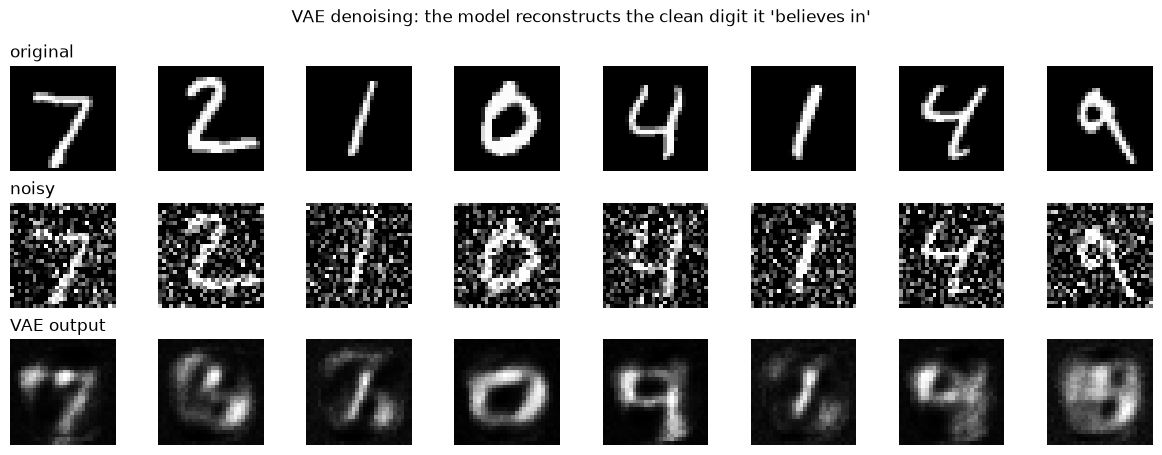

Compare the printed MSEs: the VAE output is closer to the original than
the noisy input — denoising achieved without ever training on noise.


In [1]:
# WHAT/WHY: train a VAE on clean MNIST, then use it as a DENOISER: encode a
# noise-corrupted digit, decode, and measure how much closer to the original
# the reconstruction is (MSE printed) than the noisy input was.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT = 16

dataset = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(12_800))
loader  = torch.utils.data.DataLoader(subset, batch_size=128, shuffle=True)

class VAE(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        # Encoder: image → hidden features → two heads (mean, log-variance)
        self.enc_fc = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        # Decoder: latent vector → image (Sigmoid keeps pixels in [0, 1])
        self.dec_fc = nn.Sequential(nn.Linear(z, 256), nn.ReLU(),
                                    nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc_fc(x)
        return self.mu(h), self.logvar(h)
    def reparameterise(self, mu, lv):
        # z = mu + sigma*eps: sampling that gradients can flow through
        return mu + (0.5 * lv).exp() * torch.randn_like(mu)
    def decode(self, z):
        return self.dec_fc(z).view(-1, 1, 28, 28)
    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparameterise(mu, lv)
        return self.decode(z), mu, lv

model = VAE(z=LATENT)
opt = optim.Adam(model.parameters(), lr=1e-3)

# ── Train on CLEAN digits only (5 epochs) ─────────────────────────────────
for epoch in range(5):
    for x, _ in loader:
        recon, mu, lv = model(x)
        loss = (F.binary_cross_entropy(recon, x, reduction='sum')
                - 0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
    print(f"Epoch {epoch+1}/5 — loss/image: {loss.item():.1f}")
model.eval()

# ── Corrupt unseen test digits with Gaussian pixel noise ──────────────────
test_ds = torchvision.datasets.MNIST('/tmp/mnist', train=False, transform=T.ToTensor())
clean = torch.stack([test_ds[i][0] for i in range(8)])
noisy = (clean + 0.4 * torch.randn_like(clean)).clamp(0, 1)

# ── Denoise: just encode + decode the noisy images ────────────────────────
with torch.no_grad():
    denoised, _, _ = model(noisy)

# ── Verify with numbers: is the reconstruction closer to the original? ────
mse_noisy    = F.mse_loss(noisy,    clean).item()
mse_denoised = F.mse_loss(denoised, clean).item()
print(f"\nMSE vs original — noisy input: {mse_noisy:.4f}   after VAE: {mse_denoised:.4f}")

fig, axes = plt.subplots(3, 8, figsize=(12, 4.6))
for i in range(8):
    axes[0, i].imshow(clean[i].squeeze(),    cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(noisy[i].squeeze(),    cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(denoised[i].squeeze(), cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_title("original", loc='left'); axes[1, 0].set_title("noisy", loc='left')
axes[2, 0].set_title("VAE output", loc='left')
plt.suptitle("VAE denoising: the model reconstructs the clean digit it 'believes in'")
plt.tight_layout(); plt.show()
print("Compare the printed MSEs: the VAE output is closer to the original than")
print("the noisy input — denoising achieved without ever training on noise.")


## Hands-On 2 — 🌍 Anomaly Detection (production pattern)

**Industry context:** assembly-line defect detection, payment fraud scoring, anomalous-scan flagging — all run this exact pattern: model the *normal* class, threshold the reconstruction error.


Epoch 0 — loss: 314.82


Epoch 5 — loss: 145.82


Epoch 10 — loss: 123.09



Reconstruction error — Normal (0): 0.0183  Anomaly (8): 0.0588


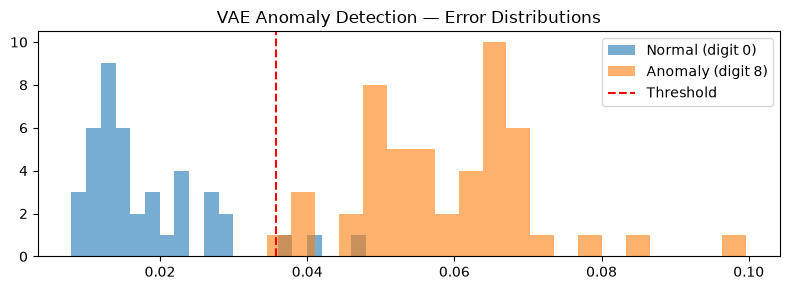

In [2]:
# WHAT/WHY: the anomaly-detection pattern from example 01, kept here as the
# second hands-on application: train on digit 0 only, then unseen digit 8
# reconstructs badly and crosses the error threshold.
torch.manual_seed(42)

# ── "Normal" training data: the first 2000 images of digit 0 only ─────────
idx_0 = [i for i, (x, y) in enumerate(dataset) if y == 0][:2000]
normal_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, idx_0), batch_size=64, shuffle=True)

anomaly_model = VAE()
opt = optim.Adam(anomaly_model.parameters(), lr=1e-3)


# ── Train the VAE on normals only — it never sees an 8 ────────────────────
for epoch in range(15):
    total = 0
    for x, _ in normal_loader:
        recon, mu, lv = anomaly_model(x)
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum()
        loss = recon_loss + 0.5 * kl_loss
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if epoch % 5 == 0:
        print(f"Epoch {epoch} — loss: {total/len(idx_0):.2f}")


# ── Score held-out digits: reconstruction error is the anomaly signal ─────
anomaly_model.eval()
samples_0 = torch.stack([test_ds[i][0] for i in range(500)  if test_ds[i][1] == 0][:50])
samples_8 = torch.stack([test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8][:50])

def recon_error(imgs):
    with torch.no_grad():
        recon, _, _ = anomaly_model(imgs)
        return F.mse_loss(recon, imgs, reduction='none').view(len(imgs), -1).mean(1)

err_0 = recon_error(samples_0).numpy()
err_8 = recon_error(samples_8).numpy()
print(f"\nReconstruction error — Normal (0): {err_0.mean():.4f}  Anomaly (8): {err_8.mean():.4f}")


# ── Plot both error distributions; the threshold line separates them ──────
plt.figure(figsize=(8, 3))
plt.hist(err_0, bins=20, alpha=0.6, label="Normal (digit 0)")
plt.hist(err_8, bins=20, alpha=0.6, label="Anomaly (digit 8)")
plt.axvline(err_0.mean() + 2 * err_0.std(), color='red', linestyle='--', label="Threshold")
plt.legend(); plt.title("VAE Anomaly Detection — Error Distributions"); plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- An & Cho (2015) — [Variational Autoencoder based Anomaly Detection](https://www.semanticscholar.org/paper/Variational-Autoencoder-based-Anomaly-Detection-An-Cho/061146b1d7938d7a8dae70e3531a00fceb3c78e8)
- Karras et al. (2019) — [StyleGAN](https://arxiv.org/abs/1812.04948) *(the production approach to face generation)*
- Pang et al. (2021) — [Deep Learning for Anomaly Detection: A Review](https://arxiv.org/abs/2007.02500) *(ACM Computing Surveys; where reconstruction-based detection fits)*

**Datasets to try with a GPU:** [CelebA](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html), [FFHQ](https://github.com/NVlabs/ffhq-dataset)


## 📝 Summary

In **02 — VAE Applications** you saw four applications of one architecture: face generation and style transfer as recipes (their full-scale training is beyond classroom hardware — the references show the way), and two applications **run and verified here**: denoising (the VAE output's MSE to the original beat the noisy input's — see printed numbers) and anomaly detection (the unseen class produced clearly higher reconstruction errors). Advanced variants — conditional VAEs and β-VAE — are next, in example 03.
